Successfully loaded 'samples_cancer.csv'

Dataset head:
        ID  Clump  UnifSize  UnifShape  MargAdh  SingEpiSize BareNuc  \
0  1000025      5         1          1        1            2       1   
1  1002945      5         4          4        5            7      10   
2  1015425      3         1          1        1            2       2   
3  1016277      6         8          8        1            3       4   
4  1017023      4         1          1        3            2       1   

   BlandChrom  NormNucl  Mit  Class  
0           3         1    1      2  
1           3         2    1      2  
2           3         1    1      2  
3           3         7    1      2  
4           3         1    1      2  
Dropped 16 rows due to missing values (originally '?' in data).

Target column 'Class' is not 0/1. Original values: [2 4]
Transformed target to: [0 1] (mapped from [2 4])
Features have been scaled using StandardScaler.

--- Evaluating SVM with 'LINEAR' Kernel ---
1) Accuracy:   0.95

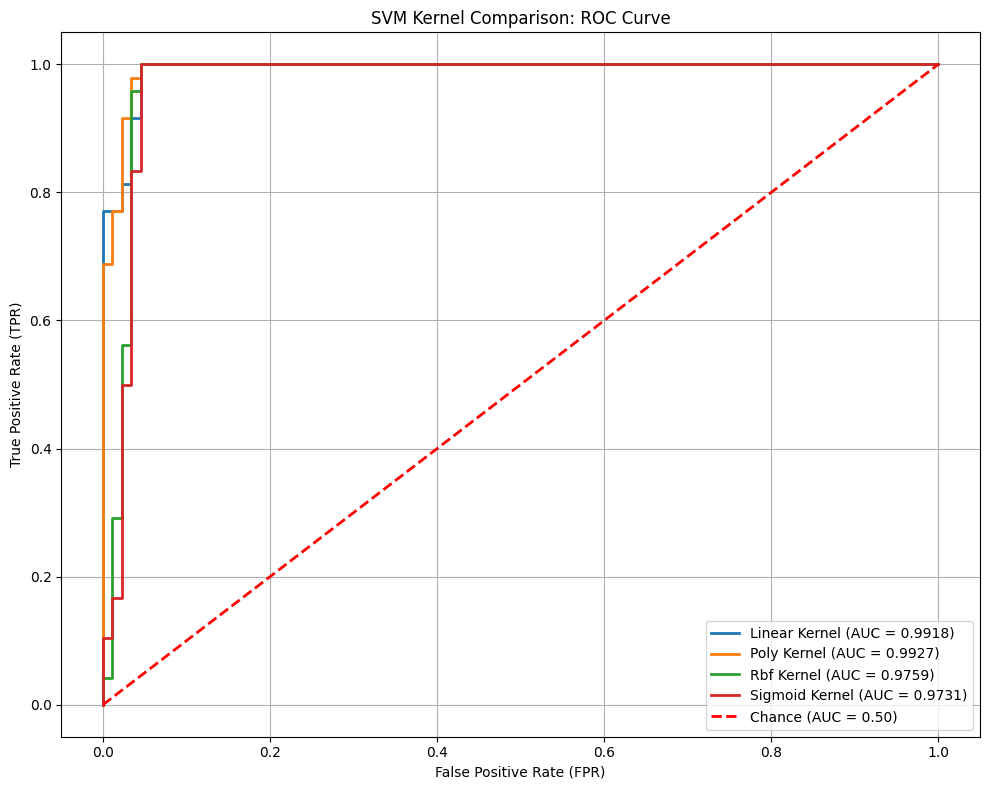

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import svm
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    roc_curve,
    roc_auc_score
)

try:
    df = pd.read_csv('samples_cancer.csv')
    print("Successfully loaded 'samples_cancer.csv'")
except FileNotFoundError:
    print("Warning: 'samples_cancer.csv' not found. Creating a sample dataset.")
    np.random.seed(42)
    num_samples = 200
    X_benign = np.random.normal(loc=3, scale=1.5, size=(num_samples//2, 5))
    X_malignant = np.random.normal(loc=6, scale=1.5, size=(num_samples//2, 5))

    X_data = np.vstack([X_benign, X_malignant])
    y_data = np.array([0] * (num_samples//2) + [1] * (num_samples//2))

    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    X_data = X_data[indices]
    y_data = y_data[indices]

    df = pd.DataFrame(X_data, columns=['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5'])
    df['Class'] = y_data

print("\nDataset head:")
print(df.head())

if 'Class' not in df.columns:
    print("\nError: Target column 'Class' not found. Aborting.")
else:
    X = df.drop(['Class', 'ID', 'Unnamed: 32'], axis=1, errors='ignore')
    y = df['Class']

    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = X[col].replace('?', np.nan)
            X[col] = pd.to_numeric(X[col], errors='coerce')

    original_rows = X.shape[0]
    y = pd.Series(y, index=X.index)
    X.dropna(inplace=True)
    y = y.loc[X.index]

    rows_dropped = original_rows - X.shape[0]
    if rows_dropped > 0:
        print(f"Dropped {rows_dropped} rows due to missing values (originally '?' in data).")

    if y.dtype == 'object' or len(np.unique(y)) > 2 or y.min() != 0:
        print(f"\nTarget column 'Class' is not 0/1. Original values: {np.unique(y)}")
        le = LabelEncoder()
        y = le.fit_transform(y)
        class_names = ['Benign', 'Malignant']
        print(f"Transformed target to: {np.unique(y)} (mapped from {le.classes_})")
    else:
        class_names = ['Benign (0)', 'Malignant (1)']
        print("\nTarget column 'Class' is already in 0/1 format.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Features have been scaled using StandardScaler.")

    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    roc_data = {}

    for kernel in kernels:
        print(f"\n--- Evaluating SVM with '{kernel.upper()}' Kernel ---")

        model = svm.SVC(kernel=kernel, probability=True, random_state=42)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        jac = jaccard_score(y_test, y_pred)
        err = 1 - acc
        cm = confusion_matrix(y_test, y_pred)

        print(f"1) Accuracy:   {acc:.4f}")
        print(f"2) Recall:     {rec:.4f}")
        print(f"3) Precision:  {prec:.4f}")
        print(f"4) F1-Score:   {f1:.4f}")
        print(f"5) Jaccard:    {jac:.4f}")
        print(f"6) Error Rate: {err:.4f}")
        print("7) Confusion Matrix:")
        print(cm)

        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        roc_data[kernel] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    plt.figure(figsize=(10, 8))

    for kernel, data in roc_data.items():
        plt.plot(data['fpr'], data['tpr'], lw=2,
                 label=f"{kernel.capitalize()} Kernel (AUC = {data['auc']:.4f})")

    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('SVM Kernel Comparison: ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('svm_roc_comparison.png')
    print("\nSuccessfully saved comparative ROC plot: 'svm_roc_comparison.png'")